In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import joblib

# About Dataset

## Context
"Predict behavior to retain customers. You can analyze all relevant customer data and develop focused customer retention programs." [IBM Sample Data Sets]

## Content
Each row represents a customer, each column contains customer’s attributes described on the column Metadata.

## The data set includes information about:

Customers who left within the last month – the column is called Churn
Services that each customer has signed up for – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies
Customer account information – how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges
Demographic info about customers – gender, age range, and if they have partners and dependents


In [2]:
df = pd.read_csv("../data/Telco-Customer-Churn.csv")

# EDA

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors="coerce") # errors="coerce" -> transforme en Nan une valeur pas convertible

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df=df.dropna()

In [9]:
df["TotalCharges"].isna().sum()

np.int64(0)

In [10]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [11]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [12]:
df.drop("customerID",axis=1,inplace=True)

In [13]:
# target
df["Churn"]=df["Churn"].map({"Yes":1,"No":0})

In [14]:
df["Churn"].head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

In [15]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## Encoding

In [16]:
df = pd.get_dummies(df, drop_first=True)

In [17]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [18]:
df=df.astype(int)

In [19]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29,29,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56,1889,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53,108,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42,1840,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70,151,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


In [20]:
df.shape

(7032, 31)

# Independent and dependent variables 

In [21]:
X=df.drop("Churn",axis=1)
y=df["Churn"]

# Split the data

In [22]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)

In [23]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5625, 30)
(1407, 30)
(5625,)
(1407,)


# Scale the data

In [29]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [34]:
pd.DataFrame(X_train_scaled)

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,-0.437590,0.434674,-0.504737,-0.087788,-1.013784,-0.962481,-0.653684,-3.040707,3.040707,-0.845541,...,-0.529847,1.261811,-0.529847,1.247260,-0.518272,-0.561130,0.831397,-0.527645,-0.714758,-0.547427
1,-0.437590,-1.195652,-0.372172,-0.921386,0.986404,-0.962481,-0.653684,0.328871,-0.328871,-0.845541,...,-0.529847,1.261811,-0.529847,-0.801758,-0.518272,-0.561130,-1.202795,1.895214,-0.714758,-0.547427
2,-0.437590,0.923772,0.423218,0.963925,-1.013784,1.038981,-0.653684,0.328871,-0.328871,1.182675,...,-0.529847,-0.792512,-0.529847,-0.801758,-0.518272,-0.561130,0.831397,-0.527645,1.399076,-0.547427
3,-0.437590,0.516190,-0.339030,0.122820,0.986404,1.038981,1.529791,0.328871,-0.328871,-0.845541,...,-0.529847,-0.792512,-0.529847,-0.801758,-0.518272,1.782119,-1.202795,-0.527645,-0.714758,-0.547427
4,-0.437590,0.923772,1.185466,1.401034,-1.013784,1.038981,1.529791,0.328871,-0.328871,1.182675,...,-0.529847,1.261811,-0.529847,1.247260,1.929487,-0.561130,-1.202795,-0.527645,-0.714758,1.826727
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5620,-0.437590,-1.195652,-0.471595,-0.943904,0.986404,-0.962481,-0.653684,0.328871,-0.328871,1.182675,...,-0.529847,-0.792512,-0.529847,-0.801758,-0.518272,-0.561130,-1.202795,-0.527645,-0.714758,-0.547427
5621,-0.437590,0.760739,1.550020,1.513623,-1.013784,-0.962481,-0.653684,0.328871,-0.328871,1.182675,...,-0.529847,1.261811,-0.529847,1.247260,1.929487,-0.561130,0.831397,-0.527645,1.399076,-0.547427
5622,-0.437590,-0.951104,0.555783,-0.658238,0.986404,-0.962481,-0.653684,0.328871,-0.328871,1.182675,...,-0.529847,-0.792512,-0.529847,-0.801758,-0.518272,-0.561130,0.831397,-0.527645,1.399076,-0.547427
5623,-0.437590,0.719981,-1.498973,-0.567725,-1.013784,-0.962481,-0.653684,0.328871,-0.328871,-0.845541,...,1.887338,-0.792512,1.887338,-0.801758,1.929487,-0.561130,-1.202795,-0.527645,-0.714758,-0.547427


# Models

## XgBoost Classifier/GradientBoostingClassifier/AdaBoost Classifier/Random Forest Classifier / Decision Tree Classifier / Logistic Regression

In [40]:
models= {
    "XgBoost":XGBClassifier(),
    "GradientBoosting":GradientBoostingClassifier(),
    "AdaBoost":AdaBoostClassifier(),
    "DecisionTree":DecisionTreeClassifier(class_weight="balanced"),
    "RandomForest":RandomForestClassifier(class_weight="balanced"),
    "LogisticRegression":LogisticRegression(class_weight="balanced")
}

for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(X_train_scaled,y_train)

    y_train_pred=model.predict(X_train_scaled)
    y_test_pred=model.predict(X_test_scaled)
    y_train_proba = model.predict_proba(X_train_scaled)[:,1]
    y_test_proba = model.predict_proba(X_test_scaled)[:,1]

    # Training set performance
    model_train_accuracy = accuracy_score(y_train,y_train_pred)
    model_train_precision = precision_score(y_train,y_train_pred)
    model_train_recall = recall_score(y_train,y_train_pred)
    model_train_f1_score = f1_score(y_train,y_train_pred, average='weighted')
    #model_train_roc_auc_score = roc_auc_score(y_train,y_train_pred)
    model_train_roc_auc_score=roc_auc_score(y_train, y_train_proba)

    # Test set performance
    model_test_accuracy = accuracy_score(y_test,y_test_pred)
    model_test_precision = precision_score(y_test,y_test_pred)
    model_test_recall = recall_score(y_test,y_test_pred)
    model_test_f1_score = f1_score(y_test,y_test_pred, average='weighted')
    #model_test_roc_auc_score = roc_auc_score(y_test,y_test_pred)
    model_test_roc_auc_score=roc_auc_score(y_test, y_test_proba)

    print("----------------------------------------")
    print(list(models.keys())[i])

    print("Model performance for training set")

    print("Accuracy :", model_train_accuracy)
    print("precison :", model_train_precision)
    print("recall :", model_train_recall)
    print("f1 score :", model_train_f1_score)
    print("roc auc score :", model_train_roc_auc_score)

    print("Model performance for test set")

    print("Accuracy :", model_test_accuracy)
    print("precison :", model_test_precision)
    print("recall :", model_test_recall)
    print("f1 score :", model_test_f1_score)
    print("roc auc score :", model_test_roc_auc_score)

----------------------------------------
XgBoost
Model performance for training set
Accuracy : 0.9416888888888889
precison : 0.9083275017494752
recall : 0.8682274247491639
f1 score : 0.9412619103351761
roc auc score : 0.9845696308113404
Model performance for test set
Accuracy : 0.7668798862828714
precison : 0.5714285714285714
recall : 0.4919786096256685
f1 score : 0.7610330962861075
roc auc score : 0.8031083858343127
----------------------------------------
GradientBoosting
Model performance for training set
Accuracy : 0.8245333333333333
precison : 0.7085385878489326
recall : 0.577257525083612
f1 score : 0.8184223557529324
roc auc score : 0.8803374444273486
Model performance for test set
Accuracy : 0.7924662402274343
precison : 0.6464285714285715
recall : 0.4839572192513369
f1 score : 0.7820675154396457
roc auc score : 0.8319649429779833
----------------------------------------
AdaBoost
Model performance for training set
Accuracy : 0.8087111111111112
precison : 0.6735708367854184
recal

J’ai comparé plusieurs modèles. Même si certains avaient une meilleure accuracy, j’ai privilégié un modèle avec un recall élevé sur la classe churn. J’ai donc retenu une logistic regression avec class_weight balanced, qui détecte près de 80% des churners.

In [52]:
params = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l1", "l2", "elasticnet", None],
    "solver": ["lbfgs"]
}

In [53]:
grid=GridSearchCV(
    LogisticRegression(class_weight="balanced", max_iter=1000),
    param_grid=params,
    scoring="recall",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

c:\Users\nico_\Desktop\Churn project\venvchurn\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
40 fits failed out of a total of 80.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\nico_\Desktop\Churn project\venvchurn\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\nico_\Desktop\Churn project\venvchurn\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\nico_\Desktop\Churn project\venvchurn\lib\site-packages\sklearn\linear_model\_logistic

,estimator,LogisticRegre...max_iter=1000)
,param_grid,"{'C': [0.01, 0.1, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['lbfgs']}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [54]:
print(grid.best_params_)

{'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}


In [55]:
print(grid.best_score_)

0.7986622073578596


Le modèle détecte environ 80% des churners

In [56]:
best_model = grid.best_estimator_

In [57]:
y_pred = best_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1033
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.75      1407



Le modèle atteint un recall de 79% sur les churners, ce qui permet de détecter efficacement les clients à risque. J’ai volontairement accepté une baisse de précision afin de maximiser la détection, ce qui est cohérent dans un contexte business.

c:\Users\nico_\Desktop\Churn project\venvchurn\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


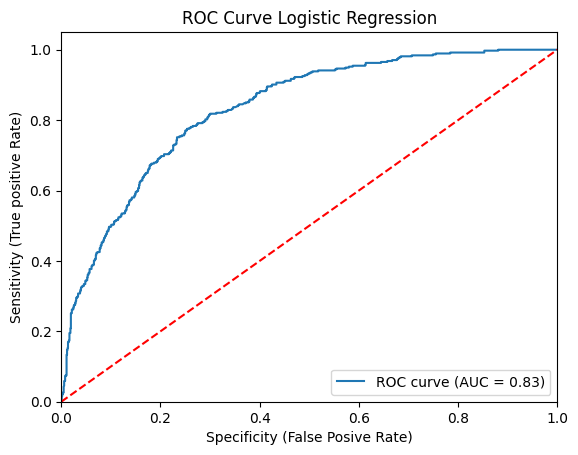

In [59]:
# Plot ROC AUC Curve
plt.figure()
auc_models = [
    {
        'label': 'Logistic Regression',
        'model': LogisticRegression(C= 1, penalty= "l2", solver= "lbfgs")
    }]

for algo in auc_models:
    model = algo["model"]
    model.fit(X_train_scaled,y_train)

    fpr,tpr,thresholds = roc_curve(y_test, model.predict_proba(X_test_scaled)[:,1])

    y_test_pred=model.predict(X_test)

    model_test_roc_auc_score = roc_auc_score(y_test,model.predict_proba(X_test_scaled)[:,1])
    
    plt.plot(fpr,tpr, label=f"ROC curve (AUC = {model_test_roc_auc_score:.2f})")

plt.plot([0,1],[0,1],'r--')
plt.xlim([0.0,1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Specificity (False Posive Rate)')
plt.ylabel('Sensitivity (True positive Rate)')
plt.legend(loc="lower right")
plt.title("ROC Curve Logistic Regression")
plt.show()

# Save

In [63]:
joblib.dump(best_model, "../models/model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(X.columns, "../models/features.pkl")

['../models/features.pkl']

# Simulation

In [68]:
def simulate_change(model,scaler,features,input_data,feature,new_value):
    # Transformation data frame
    df=pd.DataFrame([input_data])
    # Réalignement colonnes
    df=df.reindex(columns=features,fill_value=0)
    # Modification de la variable
    df[feature]=new_value
    # Scaler
    df_scaled=scaler.transform(df)
    # Predict
    proba=model.predict_proba(df_scaled)[0][1]
    return proba

## Monthlycharges

In [69]:
# exemple
sample = X_test.iloc[0].to_dict()
simulate_change(best_model, scaler, X.columns, sample, "MonthlyCharges", sample["MonthlyCharges"])

np.float64(0.01601865705137319)

In [70]:
# Baisse du prix
simulate_change(best_model, scaler, X.columns, sample, "MonthlyCharges", sample["MonthlyCharges"] - 20)

np.float64(0.024455552415668328)

La baisse du prix n'est pas responsable des départs de clients

## Tenure

In [74]:
simulate_change(best_model, scaler, X.columns, sample, "tenure", sample["tenure"])

np.float64(0.5963654591688661)

In [72]:
simulate_change(best_model, scaler, X.columns, sample, "tenure", sample["tenure"] + 12)

np.float64(0.43198001564629024)

Plus l'ancienneté augmente, moins le client part

## Contract_two_year

In [77]:
simulate_change(best_model, scaler, X.columns, sample, "Contract_Two year",sample["Contract_Two year"])

np.float64(0.5963654591688661)

In [73]:
simulate_change(best_model, scaler, X.columns, sample, "Contract_Two year", 1)

np.float64(0.2624219128342413)

Plus la durée de contrat augmente, moiuns le client part

# Agent

## Tool

In [ ]:
# Tool prediction


# Tool preprocessing

def preprocess_input(input_data, features):
    import pandas as pd
    
    df = pd.DataFrame([input_data])
    
    # one-hot encoding
    df = pd.get_dummies(df)
    
    # aligner avec features du modèle
    df = df.reindex(columns=features, fill_value=0)
    
    return df


# Tool prediction

def predict_churn(input_data):
    df = preprocess_input(input_data, features)
    df_scaled = scaler.transform(df)
    
    proba = model.predict_proba(df_scaled)[0][1]
    return proba


# Tool simulation

def simulate_change(model, scaler, features, input_data, feature, new_value):
    df = preprocess_input(input_data, features)
    
    df[feature] = new_value
    
    df_scaled = scaler.transform(df)
    
    proba = model.predict_proba(df_scaled)[0][1]
    return proba


# Tool recommandation

def agent_recommendation(input_data):
    
    churn = predict_churn(input_data)
    
    context = []
    insights = []
    recommendations = []
    
     # CONTEXT 
    if input_data.get("SeniorCitizen") == 1:
        context.append("Senior customer → may require more support")
    
    if input_data.get("Partner") == "No":
        context.append("No partner → potentially lower engagement")
    
    if input_data.get("Dependents") == "No":
        context.append("No dependents → lower switching cost")
    
    if input_data.get("gender") == "Female":
        context.append("Segment may require tailored engagement")

    # ANALYSE 
    
    # Engagement
    if input_data.get("tenure", 0) < 12:
        insights.append("Low tenure")
        recommendations.append("Implement onboarding and loyalty program")
    
    if input_data.get("Contract") == "Month-to-month":
        insights.append("Short-term contract")
        recommendations.append("Offer long-term contract")
    
    # Services
    if input_data.get("TechSupport") == "No":
        insights.append("No technical support")
        recommendations.append("Promote technical support services")
    
    if input_data.get("OnlineSecurity") == "No":
        recommendations.append("Offer security add-on")
    
    if input_data.get("OnlineBackup") == "No":
        recommendations.append("Offer backup service")
    
    if input_data.get("DeviceProtection") == "No":
        recommendations.append("Promote device protection plan")
    
    # Internet
    if input_data.get("InternetService") == "Fiber optic":
        insights.append("Fiber optic users tend to churn more")
        recommendations.append("Improve perceived value or support")
    
    # Pricing
    if input_data.get("MonthlyCharges", 0) > 80:
        insights.append("High monthly charges")
        recommendations.append("Propose discount or bundle")
    
    # Payment
    if input_data.get("PaymentMethod") == "Electronic check":
        insights.append("Risky payment method")
        recommendations.append("Encourage automatic payment")
    
    # Experience
    if input_data.get("StreamingTV") == "No" and input_data.get("StreamingMovies") == "No":
        insights.append("Low entertainment engagement")
        recommendations.append("Promote entertainment bundle")
    
    # Phone usage
    if input_data.get("MultipleLines") == "No":
        recommendations.append("Upsell multiple lines")
    
    if input_data.get("PhoneService") == "No":
        recommendations.append("Offer phone service bundle")
    
    # Billing
    if input_data.get("PaperlessBilling") == "Yes":
        recommendations.append("Ensure billing transparency and clarity")
    
    
    # PRIORISATION (même actions, niveau d'urgence différent)
    
    if churn > 0.7:
        risk_level = "High churn risk"
        recommendations = [f"URGENT: {rec}" for rec in recommendations]
    
    elif churn > 0.4:
        risk_level = "Medium churn risk"
    
    else:
        risk_level = "Low churn risk"
        recommendations = ["Maintain engagement and monitor customer satisfaction"]
    
    
    return {
        "churn_probability": round(churn, 3),
        "risk_level": risk_level,
        "context": context[:3],
        "key_insights": insights[:5],
        "recommendations": recommendations[:5]
    }